In [9]:
# load packages
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [10]:
while not os.getcwd().endswith("Simglucose_suite"):
    os.chdir("..")

os.getcwd()

'/faststorage/project/GGSpeciale/GGSpeciale/Simglucose_suite'

# Notebook: compare optimal parameters between model

Iterate over optuna parameter search, and visualize best parameters across patients.
Propose best shared parameters for all patients

In [11]:
folder_path = Path("./optuna_runs/env_closed_action_history/test_noisy")
file_name = "trials.csv"

metrics = []
patients = []

for folder in folder_path.iterdir():

    print(f"loading {folder.name}")

    if folder.is_dir():        
        file_path = folder / file_name

        patients.append(folder.name)
        metrics.append(pd.read_csv(file_path))

metrics_df = pd.concat(metrics, keys=patients)

loading adult-001_clarke_risk
loading adult-003_clarke_risk
loading adult-001_positive
loading adult-003_positive
loading adult-002_positive
loading adult-002_clarke_risk


In [12]:
metrics_df.sort_values(by="value", ascending=False).tail(15)

number      value     state  params_batch_size  \
adult-003_clarke_risk 5        5  31.411320  COMPLETE                 60   
                      1        1  27.602900  COMPLETE                160   
adult-003_positive    12      12  25.515650    PRUNED                240   
                      5        5  25.023012  COMPLETE                480   
                      3        3  24.761009  COMPLETE                480   
                      0        0  24.593103  COMPLETE                 60   
adult-002_positive    12      12  23.039455    PRUNED                240   
                      11      11  20.510401    PRUNED                240   
adult-003_clarke_risk 8        8        NaN    PRUNED                320   
                      9        9        NaN    PRUNED                320   
adult-001_positive    0        0        NaN    PRUNED                320   
                      5        5        NaN    PRUNED                320   
adult-003_positive    4        4        NaN    PRUNED                320   
adult-002_positive    0        0        NaN    PRUNED                320   
adult-002_clarke_risk 1        1        NaN    PRUNED                320   

                          params_clip_range  params_ent_coef  \
adult-003_clarke_risk 5            0.261060           0.0001   
                      1            0.106705           0.0200   
adult-003_positive    12           0.147566           0.0050   
                      5            0.210742           0.1000   
                      3            0.082342           0.0500   
                      0            0.273650           0.1000   
adult-002_positive    12           0.235463           0.0010   
                      11           0.295998           0.0010   
adult-003_clarke_risk 8                 NaN              NaN   
                      9                 NaN              NaN   
adult-001_positive    0                 NaN              NaN   
                      5                 NaN              NaN   
adult-003_positive    4                 NaN              NaN   
adult-002_positive    0                 NaN              NaN   
adult-002_clarke_risk 1                 NaN              NaN   

                          params_gae_lambda  params_gamma  \
adult-003_clarke_risk 5            0.931278      0.980317   
                      1            0.982291      0.982893   
adult-003_positive    12           0.919710      0.980283   
                      5            0.857607      0.998260   
                      3            0.869350      0.995324   
                      0            0.872301      0.998293   
adult-002_positive    12           0.894619      0.998932   
                      11           0.901458      0.999045   
adult-003_clarke_risk 8                 NaN           NaN   
                      9                 NaN           NaN   
adult-001_positive    0                 NaN           NaN   
                      5                 NaN           NaN   
adult-003_positive    4                 NaN           NaN   
adult-002_positive    0                 NaN           NaN   
adult-002_clarke_risk 1                 NaN           NaN   

                          params_learning_rate  params_max_grad_norm  \
adult-003_clarke_risk 5               0.000033              0.977364   
                      1               0.000011              0.338259   
adult-003_positive    12              0.000483              0.300518   
                      5               0.000036              0.951289   
                      3               0.000019              0.635138   
                      0               0.000113              0.635145   
adult-002_positive    12              0.000259              0.451744   
                      11              0.000467              0.335092   
adult-003_clarke_risk 8                    NaN                   NaN   
                      9                    NaN                   NaN   
adult-001_posit

In [13]:
metrics_df.loc["adult-003_positive"].sort_values(by="value", ascending=False)

,number,value,state,params_batch_size,params_clip_range,params_ent_coef,params_gae_lambda,params_gamma,params_learning_rate,params_max_grad_norm,params_n_epochs,params_n_steps,params_net_arch,params_vf_coef,user_attrs_best_mean_reward,duration,datetime_start,datetime_complete
13,13,100.069122,COMPLETE,160,0.152762,0.0000,0.920020,0.982905,0.000438,0.425733,9.0,960,"128,128",0.424087,100.069122,0 days 00:28:30.670076,2026-05-27 21:37:40.178329,2026-05-27 22:06:10.848405
11,11,98.230988,COMPLETE,120,0.140978,0.0050,0.914732,0.980648,0.000482,0.311071,10.0,960,"128,128",0.203843,98.230988,0 days 00:29:21.662682,2026-05-27 21:03:19.736268,2026-05-27 21:32:41.398950
10,10,94.962532,COMPLETE,120,0.151608,0.0050,0.912100,0.981223,0.000481,0.384249,9.0,960,"128,128",0.204195,94.962532,0 days 00:29:18.081892,2026-05-27 20:34:01.406213,2026-05-27 21:03:19.488105
14,14,51.461018,COMPLETE,160,0.156394,0.0000,0.938137,0.984220,0.000216,0.437350,9.0,960,"128,128,64",0.480475,51.461018,0 days 00:28:26.848156,2026-05-27 22:06:11.106405,2026-05-27 22:34:37.954561
1,1,39.213074,COMPLETE,120,0.076207,0.0050,0.877833,0.988411,0.000092,0.971994,13.0,960,"128,128",0.257928,39.213074,0 days 00:29:10.706627,2026-05-27 16:42:59.737234,2026-05-27 17:12:10.443861
7,7,37.497658,COMPLETE,160,0.089742,0.0050,0.958379,0.992068,0.000050,0.713491,12.0,1440,"256,128",0.431544,37.497658,0 days 00:27:59.057466,2026-05-27 19:11:39.142422,2026-05-27 19:39:38.199888
9,9,36.423588,COMPLETE,120,0.198243,0.0001,0.970867,0.994698,0.000016,0.742120,15.0,1920,"256,128",0.569453,36.423588,0 days 00:28:08.169952,2026-05-27 20:05:52.982722,2026-05-27 20:34:01.152674
2,2,35.862026,COMPLETE,120,0.229754,0.0010,0.984982,0.994580,0.000013,0.909090,7.0,1920,"128,128",0.683463,35.862026,0 days 00:30:06.530867,2026-05-27 17:12:10.669886,2026-05-27 17:42:17.200753
8,8,33.854996,COMPLETE,480,0.058763,0.0001,0.892307,0.986231,0.000199,0.547287,5.0,480,"256,256",0.267048,33.854996,0 days 00:26:14.322392,2026-05-27 19:39:38.443039,2026-05-27 20:05:52.765431
6,6,33.703663,COMPLETE,60,0.297139,0.0200,0.929794,0.996999,0.000017,0.803354,14.0,1920,"256,128",0.967969,33.703663,0 days 00:28:00.074838,2026-05-27 18:43:38.854264,2026-05-27 19:11:38.929102


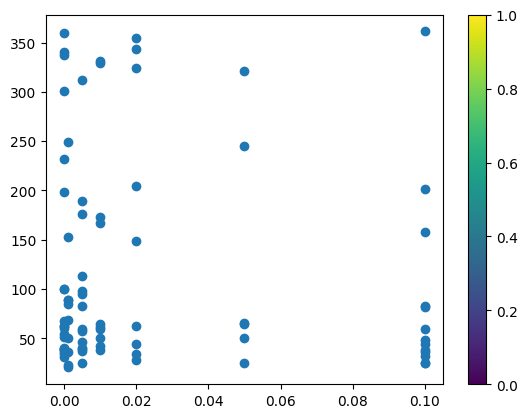

In [14]:
plt.scatter(metrics_df["params_ent_coef"], metrics_df["value"])
plt.colorbar()